#Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

**Ans:-** Anomaly Detection is the process of identifying data points, patterns, or observations that deviate significantly from normal behavior in a dataset.

Anomaly detection is commonly categorized into three types:

1. Point Anomalies

A point anomaly is a single data instance that is significantly different from the rest of the data.

Example:

In a dataset of daily temperatures, a value of 55°C on a normal summer day is a point anomaly.

In bank transactions, a 10,000 purchase made by a user who usually spends under 100 is a point anomaly.

2. Contextual Anomalies

A contextual anomaly is data that is abnormal only within a specific context, such as time, location, or season.

Example:

A temperature of 30°C is normal in summer but anomalous in winter.

High network traffic at 3 a.m. may be anomalous, even if the same traffic level is normal during the day.

3. Collective Anomalies

A collective anomaly occurs when a group of related data points, taken together, is anomalous—even if individual points may appear normal.

Example:

A sequence of small but continuous network requests may indicate a DDoS attack, even though each request looks normal.

A sudden series of minor sensor fluctuations may indicate equipment failure.


#Question 2:  Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
**Ans:-**  Isolation Forest detects anomalies by randomly partitioning the data using tree-based structures; points that are isolated quickly (with fewer splits) are considered anomalies. This approach does not rely on distance or density, making it fast, scalable, and well suited for large and high-dimensional datasets, though it may struggle with very subtle anomalies

DBSCAN, on the other hand, is a density-based clustering algorithm that identifies anomalies as points lying in low-density regions while grouping dense regions into clusters. It is especially useful for spatial data and for detecting arbitrarily shaped clusters, but it is sensitive to parameter selection and performs poorly in high-dimensional spaces.

Local Outlier Factor (LOF) also uses density, but in a local sense; it compares the density of a point with that of its nearest neighbors, allowing it to detect anomalies that are unusual only within their local neighborhood. This makes LOF effective for datasets with varying densities and local anomalies, although it is computationally expensive and sensitive to the choice of neighbors.

#Question 3: What are the key components of a Time Series? Explain each with one example.
**Ans:-** The key components of a Time Series are:-

1. The trend:- it represents the long-term movement or direction in the data over time. It shows whether the data is generally increasing, decreasing, or remaining stable. For example, a steady increase in yearly smartphone sales over several years indicates an upward trend.

2. Seasonality:- It refers to regular, repeating patterns that occur at fixed intervals such as daily, monthly, or yearly. These patterns are usually caused by seasonal factors. For example, ice cream sales increasing every summer and decreasing in winter show seasonality.

3. Cyclicality:- They involves fluctuations that occur over longer periods but do not have a fixed or predictable length like seasonality. These cycles are often influenced by economic or business conditions. For example, economic growth and recession phases affecting industrial production over several years represent cyclic behavior.

4. The irregular (or random) component:- They consists of unpredictable, random variations that cannot be attributed to trend, seasonality, or cycles. These are often caused by unexpected events. For example, a sudden drop in airline bookings due to a natural disaster is an irregular component.


#Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?
**Ans:-**  stationarity means consistent statistical behavior over time, it can be tested using plots and tests like ADF or KPSS, and non-stationary series can be made stationary through differencing, transformations, and removal of trend or seasonality.


#Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
**Ans:-** AR and MA are basic stationary models, ARIMA handles trends, SARIMA handles seasonality, and SARIMAX handles both seasonality and external influences, making each model progressively more flexible for real-world time-series applications.



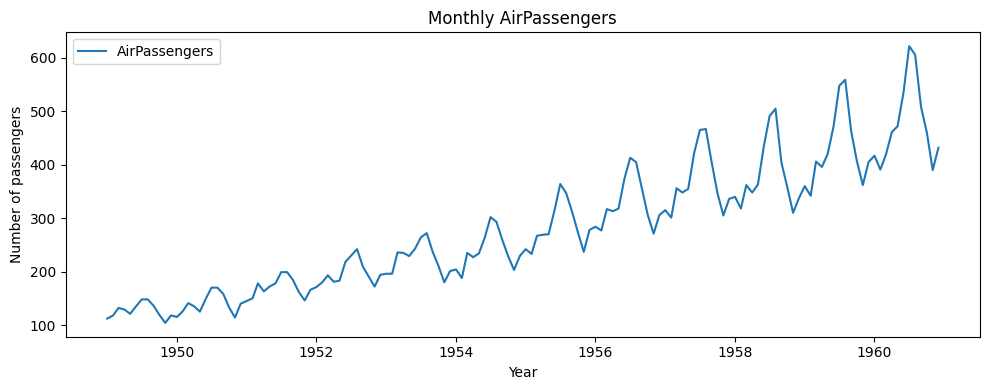

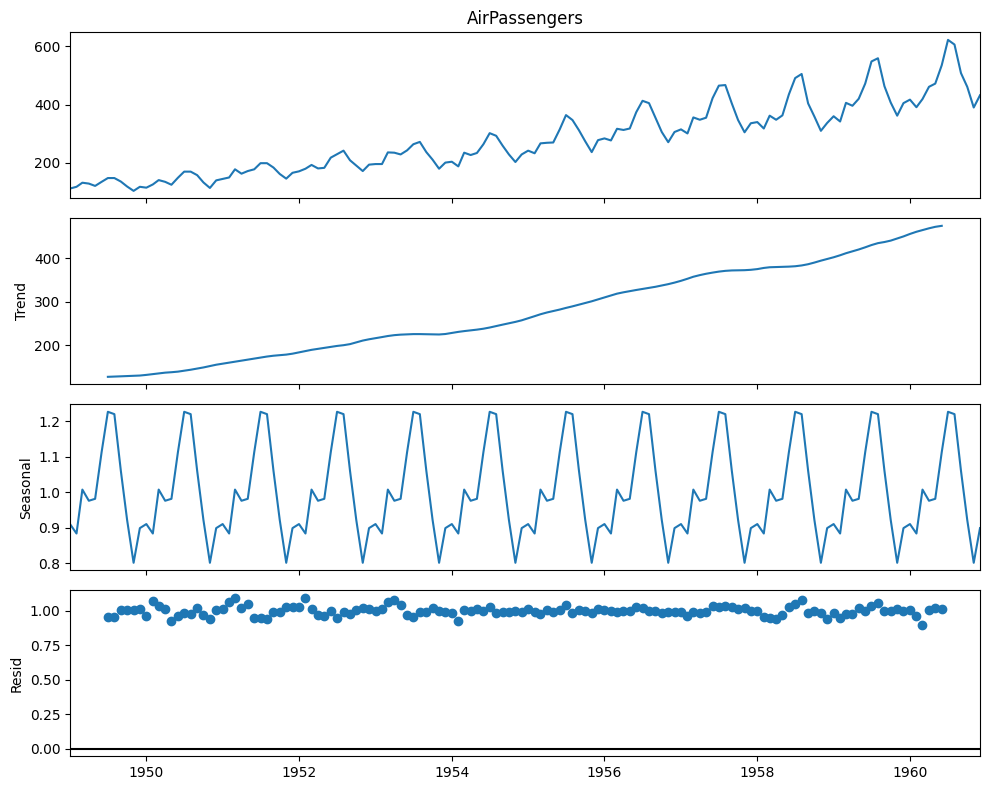

In [34]:
#Question 6:
'''
 Load a time series dataset (e.g., AirPassengers), plot the original series,
 and decompose it into trend, seasonality, and residual components
'''

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

data = sm.datasets.get_rdataset('AirPassengers', 'datasets').data

def year_float_to_datetime(year_float):
    year = int(year_float)
    month_fraction = year_float - year
    # Round to nearest month and add 1 for 1-based month index
    month = round(month_fraction * 12) + 1
    # Handle cases where rounding might result in month 0 or 13 due to float precision
    month = max(1, min(12, month))
    return pd.to_datetime(f'{year}-{month:02d}-01')

# Create a DataFrame from the loaded data for consistency with previous cells
df_raw = pd.DataFrame(data)
df_raw['Month'] = df_raw['time'].map(year_float_to_datetime)
df_raw.set_index('Month', inplace=True)
df_raw.drop(columns=['time'], inplace=True)
df_raw.rename(columns={'value': 'AirPassengers'}, inplace=True)

# Select the time series
series = df_raw['AirPassengers']
series = series.asfreq('MS')

# Plot original series
plt.figure(figsize=(10, 4))
plt.plot(series, label='AirPassengers')
plt.title('Monthly AirPassengers')
plt.xlabel('Year')
plt.ylabel('Number of passengers')
plt.legend()
plt.tight_layout()
plt.show()

# Decompose the time series
result = seasonal_decompose(series, model='multiplicative', period=12)

# Plot decomposition: trend, seasonal, residual
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

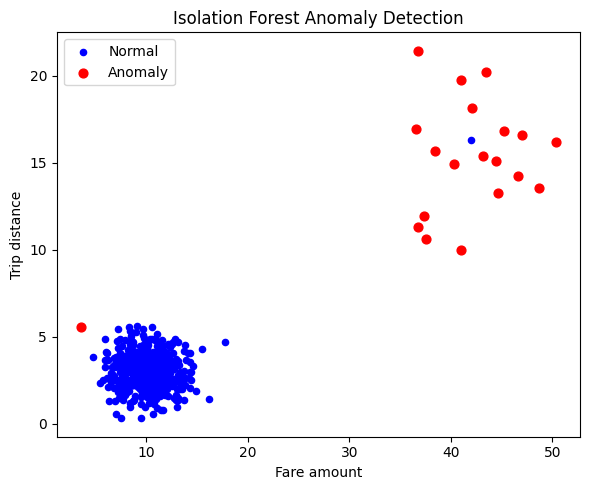

In [36]:
#Question 7:
'''
Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Simulate NYC taxi-like numerical data
np.random.seed(42)

# Normal observations
n_normal = 500
fare_normal = np.random.normal(loc=10, scale=2, size=n_normal)
trip_distance_normal = np.random.normal(loc=3, scale=1, size=n_normal)

# Anomalies: very high fare or distance
n_anom = 20
fare_anom = np.random.normal(loc=40, scale=5, size=n_anom)
trip_distance_anom = np.random.normal(loc=15, scale=3, size=n_anom)

fare = np.concatenate([fare_normal, fare_anom])
trip_distance = np.concatenate([trip_distance_normal, trip_distance_anom])

X = pd.DataFrame({
    'fare_amount': fare,
    'trip_distance': trip_distance})

# Fit Isolation Forest
iso = IsolationForest(
    contamination=n_anom / (n_normal + n_anom),
    random_state=42)
iso.fit(X)
labels = iso.predict(X)

normal_mask = labels == 1
anomaly_mask = labels == -1

# Plot anomalies
plt.figure(figsize=(6, 5))
plt.scatter(X.loc[normal_mask, 'fare_amount'],
            X.loc[normal_mask, 'trip_distance'],
            c='blue', s=20, label='Normal')
plt.scatter(X.loc[anomaly_mask, 'fare_amount'],
            X.loc[anomaly_mask, 'trip_distance'],
            c='red', s=40, label='Anomaly')
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Fare amount')
plt.ylabel('Trip distance')
plt.legend()
plt.tight_layout()
plt.show()

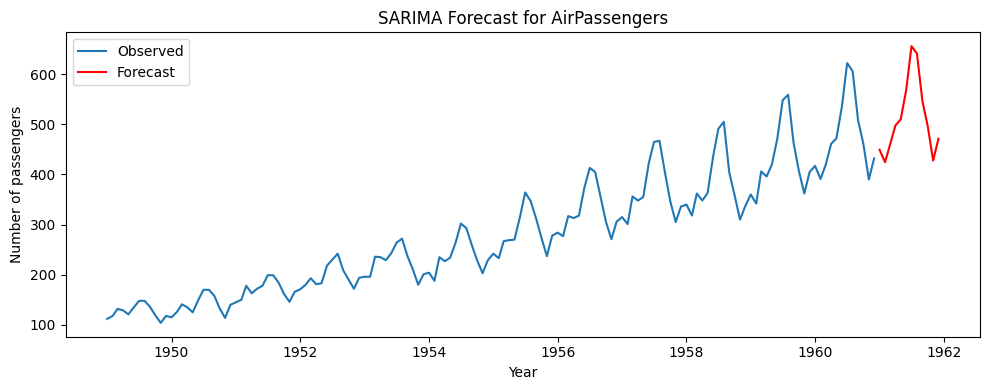

In [37]:
#Question 8:
'''
Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.
'''

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

# Load data
data = sm.datasets.get_rdataset('AirPassengers', 'datasets').data

def year_float_to_datetime(year_float):
    year = int(year_float)
    month_fraction = year_float - year
    month = round(month_fraction * 12) + 1
    month = max(1, min(12, month))
    return pd.to_datetime(f'{year}-{month:02d}-01')

df_raw = pd.DataFrame(data)
df_raw['Month'] = df_raw['time'].map(year_float_to_datetime)
df_raw.set_index('Month', inplace=True)
df_raw.drop(columns=['time'], inplace=True)
df_raw.rename(columns={'value': 'AirPassengers'}, inplace=True)

series = df_raw['AirPassengers'].asfreq('MS')
model = SARIMAX(
    series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12))

results = model.fit(disp=False)

# Forecast next 12 months
n_forecast = 12
forecast_res = results.get_forecast(steps=n_forecast)

# Build forecast index
forecast_index = pd.date_range(
    start=series.index[-1] + pd.offsets.MonthBegin(1),
    periods=n_forecast,
    freq='MS')

forecast_series = pd.Series(
    forecast_res.predicted_mean.values,
    index=forecast_index )

# Plot observed and forecasted values
plt.figure(figsize=(10, 4))
plt.plot(series, label='Observed')
plt.plot(forecast_series, label='Forecast', color='red')
plt.title('SARIMA Forecast for AirPassengers')
plt.xlabel('Year')
plt.ylabel('Number of passengers')
plt.legend()
plt.tight_layout()
plt.show()

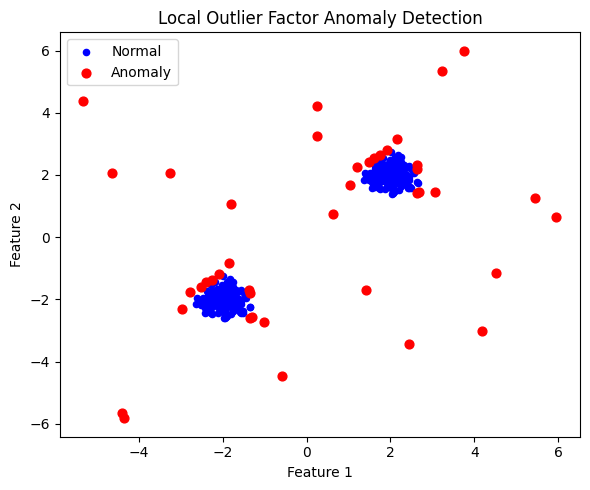

In [33]:
#Question 9:
'''
Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and
visualize them using matplotlib.
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Generate synthetic 2D data
np.random.seed(42)

# Inliers around two clusters
X_inliers = 0.3 * np.random.randn(200, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Uniform outliers
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

X = np.r_[X_inliers, X_outliers]

# Fit Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1)

y_pred = lof.fit_predict(X)

# Masks
outlier_mask = y_pred == -1
normal_mask = y_pred == 1

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X[normal_mask, 0], X[normal_mask, 1],
            c='blue', s=20, label='Normal')
plt.scatter(X[outlier_mask, 0], X[outlier_mask, 1],
            c='red', s=40, label='Anomaly')
plt.title('Local Outlier Factor Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

#Question10:-
You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.

Explain your real-time data science workflow:

1. How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?

2. Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?

3. How would you validate and monitor the performance over time?

4. How would this solution help business decisions or operations?

#Answer:-

1. Anomaly Detection Choice
I would use Isolation Forest. It is highly efficient for high-dimensional streaming data and performs well in identifying outliers (spikes/drops) by isolating them based on their unique feature values (usage vs. weather/time).

2. Time Series Model
I would use SARIMAX. Since the dataset includes external features like weather conditions, SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) allows us to incorporate these variables to improve the accuracy of short-term energy demand forecasts.

3. Validation and Monitoring
I would use a Rolling Window Validation (walk-forward validation) to monitor the Mean Absolute Percentage Error (MAPE). Performance would be monitored in real-time by comparing predicted demand against actual usage, with alerts triggered if the residual error exceeds a specific threshold.

4. Business Impact
This solution helps in Grid Stability and Cost Optimization. By detecting anomalies, the company can prevent equipment failure or blackouts. Accurate forecasting allows for better resource allocation, reducing the need for expensive "peak" power purchases